# Задание 1 `масштабирование`
Выполните масштабирование изображения car.png, которое использовалось в прошлых заданиях. Для этого:
* Считайте его с помощью библиотеки PIL.
* Приведите к размеру 32×32px, интерполяция — по умолчанию.
* Масштабированное изображение поместите в переменную `resized_image`.
* Для считывания изображения используйте функцию `Image.open` из библиотеки PIL. 
* Для масштабирования — `torchvision.transforms.v2.Resize`.

In [1]:
from PIL import Image
from matplotlib import pyplot as plt
from torchvision.transforms import Resize

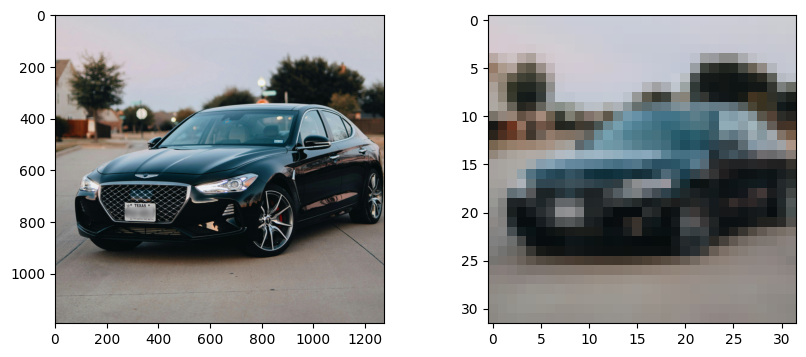

In [2]:
image = Image.open("./data/car.png")
resize = Resize((32, 32))
resized_image = resize(image)

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10,4))
ax1.imshow(image)
ax2.imshow(resized_image)
plt.show()


# Разные способы `нормализации` пикселей (цвета в каналах)

In [3]:
from torchvision.transforms.v2 import Normalize
from torchvision.transforms.functional import to_tensor


image = Image.open("./data/car.png").convert("RGB")
image_tensor = to_tensor(image)                     # нормализация не работает с PIL, только с pyTorch тензорами
image_tensor.shape

torch.Size([3, 1192, 1273])

## первый способ

In [4]:
image_tensor /= 255        # однако загруженное с помощью PIL изображение уже имеет значения в интервале [0,1]

## второй способ

In [5]:
# Вычесть примерное среднее (0.5 для интервала [0, 1]),
# Примерное std - так же 0.5
normalize = Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
normalized_image = normalize(image_tensor)

## третий способ

In [6]:
# Использовать среднее и std из конкретного датасета
# В этом примере - из датасета ImageNet
normalize = Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
normalized_image = normalize(image_tensor)

# Аугментация данных

## варьирование контрастности и тона

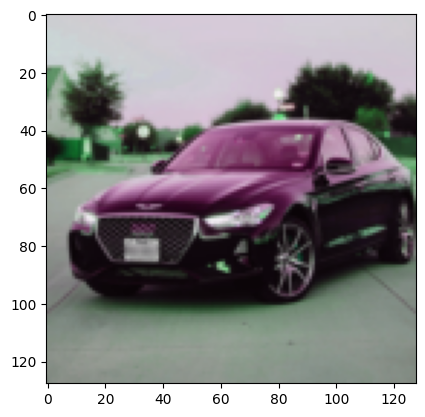

In [7]:
from torchvision.transforms.v2 import RandomPhotometricDistort

image = Image.open("./data/car.png").convert("RGB")
resize = Resize((128, 128))
resized_image = resize(image)

# Аугментация
photometric_distort = RandomPhotometricDistort(p=0.5, 
                                               contrast=[0.8, 1.2], 
                                               hue=[-0.1, 0.1])

distorted_image = photometric_distort(resized_image)

plt.imshow(distorted_image)

## отражения (flip)

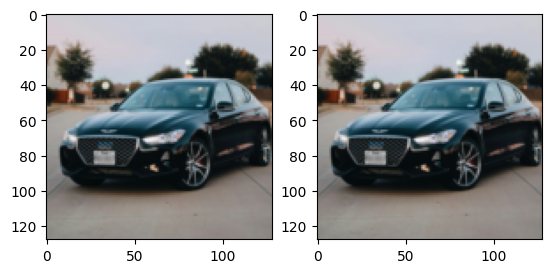

In [8]:
from torchvision.transforms.v2 import RandomHorizontalFlip, RandomVerticalFlip, Resize

image = Image.open("./data/car.png").convert('RGB')
resize = Resize((128, 128))
resized_image = resize(image)

# Аугментация
flip = RandomHorizontalFlip(p=0.5)
distorted_image = flip(resized_image)

# Визуализация результата
fig = plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(resized_image)

plt.subplot(1, 2, 2)
plt.imshow(distorted_image) 

## поворот (взгляд под углом)

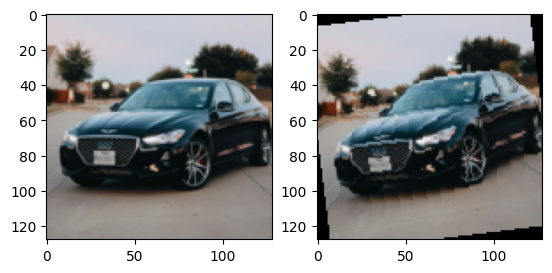

In [9]:
from torchvision.transforms.v2 import RandomRotation

image = Image.open("./data/car.png").convert('RGB')
resize = Resize((128, 128))
resized_image = resize(image)

rotate = RandomRotation((-15, 15))
distorted_image = rotate(resized_image)

fig = plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(resized_image)

plt.subplot(1, 2, 2)
plt.imshow(distorted_image) 

## пайплайн случайной комбинации искажений

100%|██████████| 26.4M/26.4M [00:41<00:00, 642kB/s] 
100%|██████████| 29.5k/29.5k [00:00<00:00, 55.5MB/s]
100%|██████████| 4.42M/4.42M [00:07<00:00, 611kB/s] 
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.93MB/s]


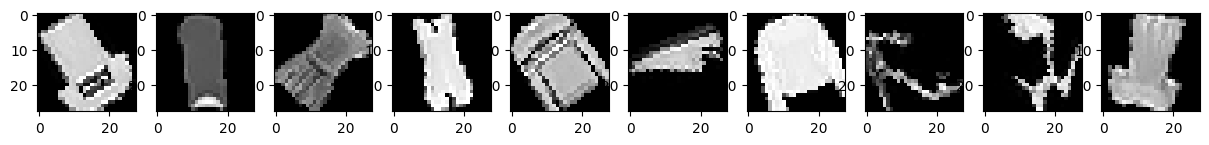

In [10]:
from torchvision.transforms.v2 import Compose
from torchvision.datasets import FashionMNIST

transforms = Compose([
    RandomHorizontalFlip(p=0.5),
    RandomVerticalFlip(p=0.5),
    RandomPhotometricDistort(p=0.5,
                             contrast=[0.8, 1.2],
                             hue=[-0.1, 0.1]),
    RandomRotation([-45, 45])
])

# Указание списка трансформаций для датасета
dataset = FashionMNIST(root='./data/', download=True, transform=transforms)

# Визуализация применения аугментации
fig = plt.figure(figsize=(15,5))
for index in range (1, 11):
    image, label = dataset[index]
    plt.subplot(1, 10, index)
    plt.imshow(image, cmap='gray')